# Employee Attrition Analysis using Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to analyze employee attrition patterns and identify the major factors influencing employee turnover.

This project uses Exploratory Data Analysis (EDA) techniques to understand how employee demographics, compensation, work environment, satisfaction levels, and career factors relate to attrition.

## Project Scope

This project focuses on identifying the key factors influencing employee attrition using Exploratory Data Analysis (EDA).

The analysis investigates relationships between employee attrition and:

- Employee demographics
- Compensation & career factors
- Work environment conditions
- Satisfaction indicators
- Experience & organizational attachment

The findings from this EDA will help understand employee turnover patterns and guide future predictive modeling.

## Analysis Methodology

The analysis was performed using a structured EDA workflow.

The approach followed includes:

1. Dataset inspection and quality checks.
2. Target variable understanding (Employee Attrition).
3. Demographic factor analysis.
4. Compensation and career-related analysis.
5. Work environment and organizational analysis.
6. Employee satisfaction analysis.
7. Correlation analysis for numerical relationships.
8. Business interpretation of findings and insights.

Each feature was analyzed using appropriate visualizations, attrition rate comparisons, and business-oriented interpretation.

### Tools Used:
- Python
- Pandas
- NumPy
- Seaborn
- Matplotlib
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Global visualization settings

sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (8,5)

plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Dataset Overview

In [3]:
df = pd.read_csv("../dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Dataset Snapshot

The dataset contains employee-level information related to:

- Demographics
- Compensation and job roles
- Work environment characteristics
- Satisfaction indicators
- Career and experience factors
- Employee attrition status

The dataset was inspected for:

- dataset structure
- missing values
- feature types
- descriptive statistics
- target variable distribution

# Target Variable Analysis

In [9]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

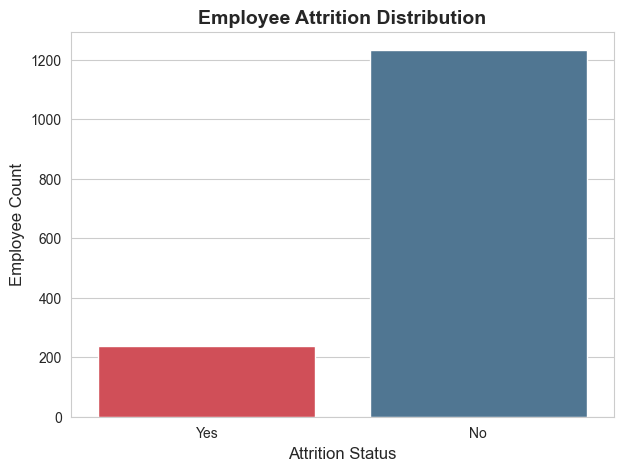

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Attrition',
    hue='Attrition',
    data=df,
    palette=['#E63946', '#45789D'],
    legend=False
)

plt.title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Status')
plt.ylabel('Employee Count')

plt.show()

# Demographic Analysis

In [11]:
df['Age'].describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

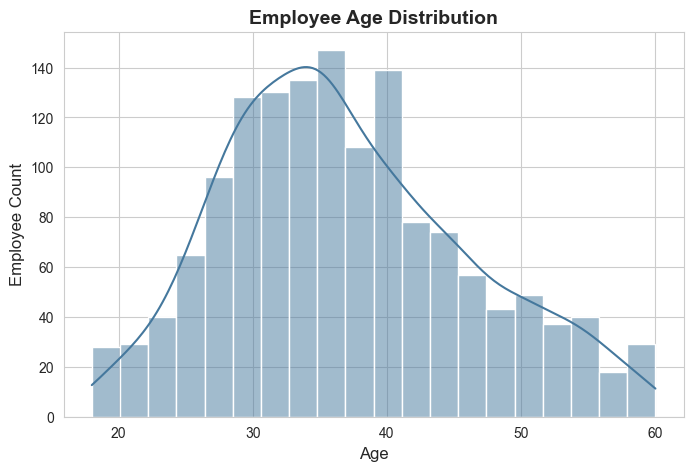

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    bins=20,
    color='#45789D',
    kde=True
)

plt.title('Employee Age Distribution',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Employee Count')

plt.show()

### Employee Age Distribution Analysis

Findings:

- Employee age ranges from 18 to 60 years.
- Most employees belong to the 30–40 age group.
- The workforce is primarily middle-aged.
- Very young and very senior employees are comparatively fewer.

Insight:

The organization appears to have a mature workforce dominated by employees in their mid-career stage.

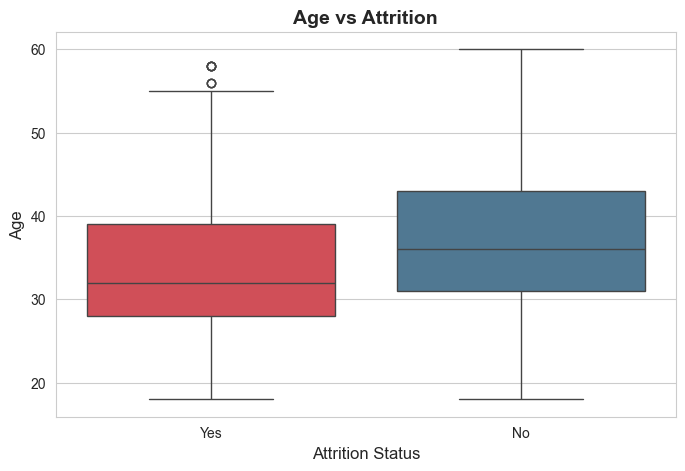

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='Age',
    hue="Attrition",
    data=df,
    palette=['#E63946', '#457B9D'],
    legend=False
)

plt.title('Age vs Attrition',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Attrition Status')
plt.ylabel('Age')

plt.show()

### Age vs Attrition Analysis

Findings:

- Employees who left the company tend to be younger.
- Median age of employees with attrition is lower than employees who stayed.
- Employees who remained in the company generally belong to slightly older age groups.

Insight:

Younger employees appear more likely to leave the organization. This may indicate career mobility, salary expectations, or early-career job switching behavior.

Outlier Observation:

Minor outliers were observed in the Age variable through boxplot analysis.

These values were retained because they fall within realistic human age ranges and represent valid employee records rather than data errors.

In [14]:
pd.crosstab(
    df['Gender'],
    df['Attrition']
)

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


In [15]:
gender_rate = pd.crosstab(
    df['Gender'],
    df['Attrition'],
    normalize='index'
) * 100

gender_rate

Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


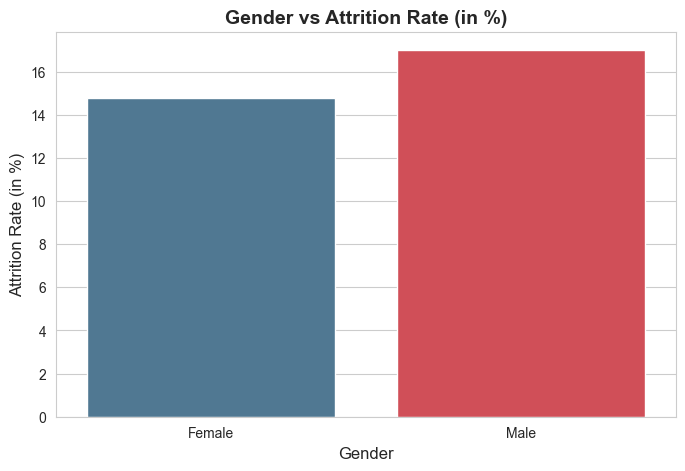

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=gender_rate.index,
    y=gender_rate['Yes'],
    hue=gender_rate.index,
    palette=['#457B9D', '#E63946'],
    legend=False
)

plt.title(
    'Gender vs Attrition Rate (in %)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Gender')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Gender vs Attrition Analysis

### Findings:

- Male employees show slightly higher attrition (~17.0%).
- Female employees show slightly lower attrition (~14.8%).
- The difference exists but is not extremely large.

### Insight:

Gender alone does not appear to be a dominant driver of employee attrition.

Employee turnover may be influenced more strongly by factors such as:

- overtime
- salary
- job satisfaction
- work-life balance
- career growth

rather than gender itself.

In [17]:
pd.crosstab(
    df['MaritalStatus'],
    df['Attrition']
)

Attrition,No,Yes
MaritalStatus,,
Divorced,294,33
Married,589,84
Single,350,120


In [18]:
marital_rate = pd.crosstab(
    df['MaritalStatus'],
    df['Attrition'],
    normalize='index'
) * 100

marital_rate

Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915


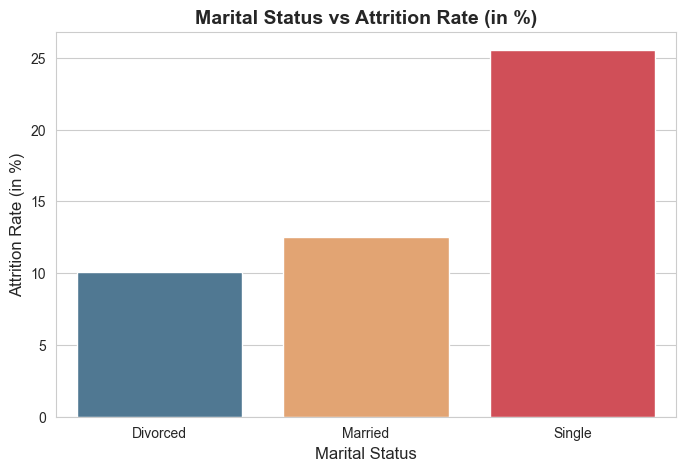

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=marital_rate.index,
    y=marital_rate['Yes'],
    hue=marital_rate.index,
    palette=['#457B9D', '#F4A261', '#E63946'],
    legend=False
)

plt.title(
    'Marital Status vs Attrition Rate (in %)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Marital Status')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Marital Status vs Attrition Analysis
### Findings:
Single employees show the highest attrition rate (~25–26%).
Married employees show moderate attrition (~12–13%).
Divorced employees show the lowest attrition (~10%).

Clear pattern:

Single employees are significantly more likely to leave the organization.

### Insight:

Marital status appears associated with employee retention.

Single employees may:

explore career opportunities more aggressively
have greater mobility/flexibility
relocate more easily
switch jobs more readily

Married employees often may have:

family commitments
preference for job stability
lower willingness for frequent job changes

In [20]:
pd.crosstab(
    df['EducationField'],
    df['Attrition']
)

Attrition,No,Yes
EducationField,,
Human Resources,20,7
Life Sciences,517,89
Marketing,124,35
Medical,401,63
Other,71,11
Technical Degree,100,32


In [21]:
edu_rate = pd.crosstab(
    df['EducationField'],
    df['Attrition'],
    normalize='index'
) * 100

edu_rate

Attrition,No,Yes
EducationField,,
Human Resources,74.074074,25.925926
Life Sciences,85.313531,14.686469
Marketing,77.987421,22.012579
Medical,86.422414,13.577586
Other,86.585366,13.414634
Technical Degree,75.757576,24.242424


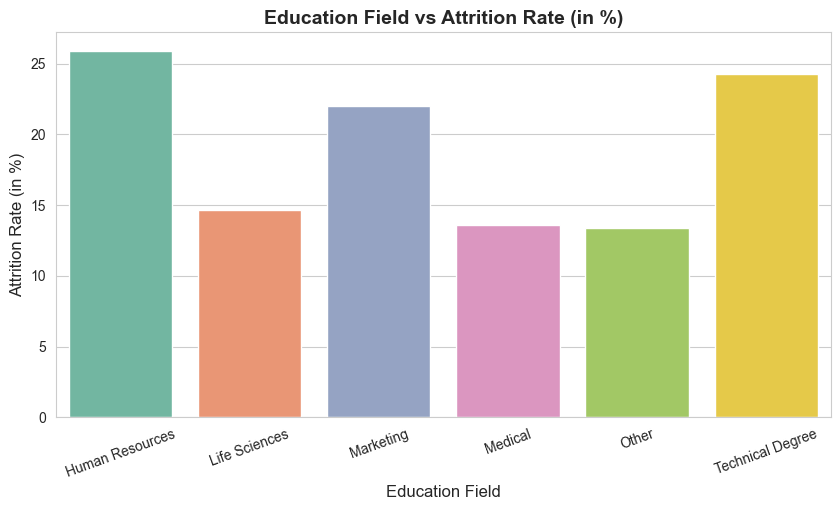

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=edu_rate.index,
    y=edu_rate['Yes'],
    hue=edu_rate.index,
    palette='Set2',
    legend=False
)

plt.title(
    'Education Field vs Attrition Rate (in %)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Education Field')
plt.ylabel('Attrition Rate (in %)')

plt.xticks(rotation=20)

plt.show()

## Education Field vs Attrition Analysis

### Findings:
Human Resources shows the highest attrition rate (~26%).
Technical Degree employees also show relatively high attrition (~24%).
Marketing has elevated attrition (~22%.
Life Sciences, Medical, and Other show comparatively lower attrition (~13–15%).

Clear variation exists across education backgrounds.

### Insight:

Educational specialization may influence employee turnover behavior.

Different education fields can lead to:

different career opportunities
varying market demand
alternative industry options
different job expectations

Fields with stronger external opportunities may demonstrate higher mobility and therefore higher attrition.

# Compensation & Career Analysis

In [23]:
df['MonthlyIncome'].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

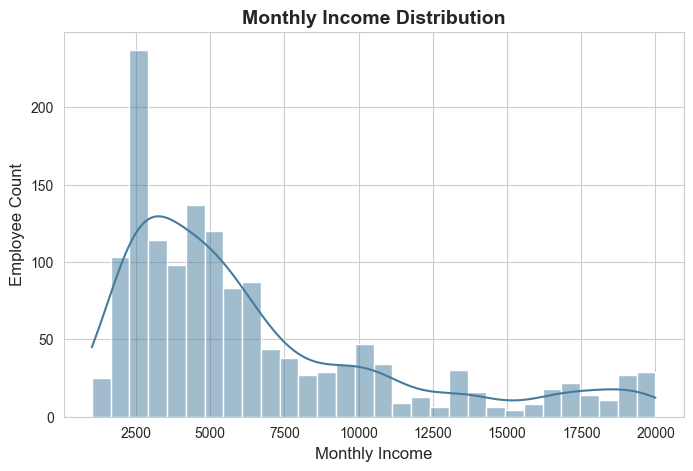

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='MonthlyIncome',
    bins=30,
    color='#457B9D',
    kde=True
)

plt.title('Monthly Income Distribution',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Monthly Income')
plt.ylabel('Employee Count')

plt.show()

## Monthly Income Distribution Analysis

### Findings:

- Monthly income shows a right-skewed distribution.
- Most employees belong to lower-to-mid salary ranges.
- A smaller group earns substantially higher salaries.

### Insight:

Income distribution is not uniform across employees, suggesting presence of multiple salary levels corresponding to job hierarchy and experience.

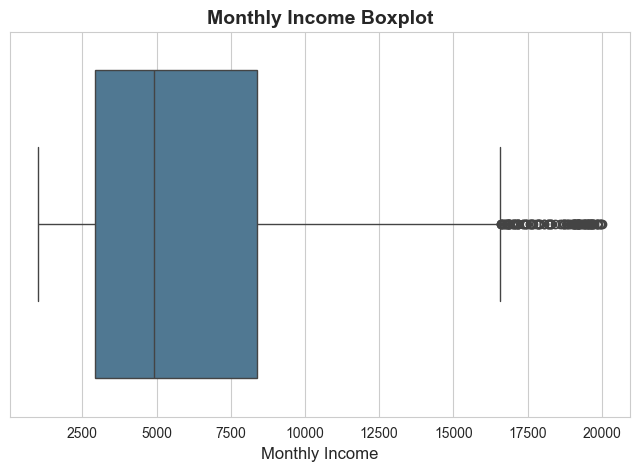

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['MonthlyIncome'],
    color='#457B9D'
)

plt.title('Monthly Income Boxplot',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Monthly Income')

plt.show()

## Monthly Income Boxplot Analysis

### Findings:

- Monthly income contains several high-value observations.
- Income distribution is right-skewed.
- Potential outliers are visible in the higher salary range.

### Outlier Decision:

These observations were retained because they likely represent senior employees or high-paying job roles rather than data entry errors.

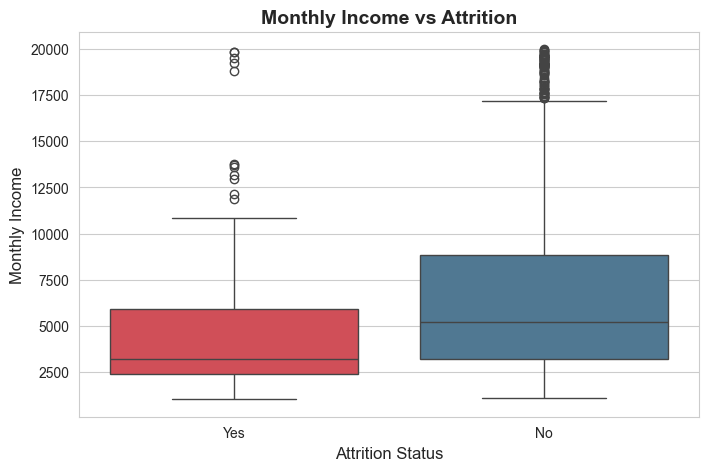

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df,
    hue='Attrition',
    palette=['#E63946', '#457B9D'],
    legend=False
)

plt.title('Monthly Income vs Attrition',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Attrition Status')
plt.ylabel('Monthly Income')

plt.show()

## Monthly Income vs Attrition Analysis

### Findings:

- Employees with lower monthly income show higher attrition tendency.
- Higher income employees appear comparatively more stable.
- Income distribution differs between attrition groups.

### Insight:

Compensation appears associated with employee retention.

Employees receiving lower salaries may be more likely to leave because of:

- compensation dissatisfaction
- better external opportunities
- career growth expectations

In [27]:
pd.crosstab(
    df['JobLevel'],
    df['Attrition']
)

Attrition,No,Yes
JobLevel,,
1,400,143
2,482,52
3,186,32
4,101,5
5,64,5


In [28]:
joblevel_rate = pd.crosstab(
    df['JobLevel'],
    df['Attrition'],
    normalize='index'
) * 100

joblevel_rate

Attrition,No,Yes
JobLevel,,
1,73.664825,26.335175
2,90.262172,9.737828
3,85.321101,14.678899
4,95.283019,4.716981
5,92.753623,7.246377


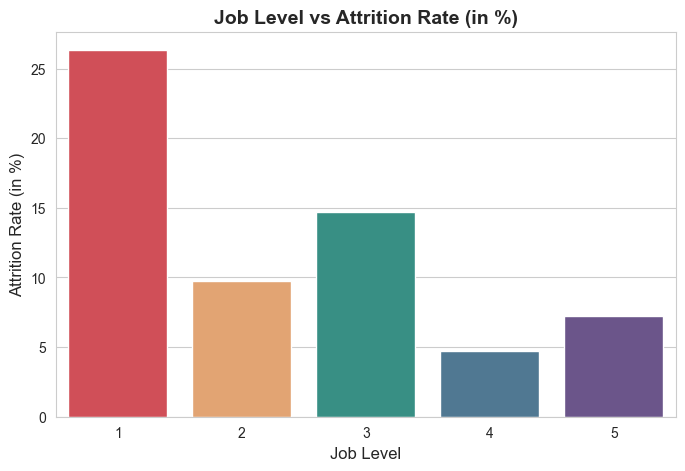

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=joblevel_rate.index,
    y=joblevel_rate['Yes'],
    hue=joblevel_rate.index,
    palette=['#E63946', '#F4A261', '#2A9D8F', '#457B9D', '#6A4C93'],
    legend=False
)

plt.title(
    'Job Level vs Attrition Rate (in %)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Job Level')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Job level vs Attrition Analysis

### Findings:
Job Level 1 shows the highest attrition rate (~26%).
Job Level 2 has considerably lower attrition (~10%).
Job Level 3 shows moderate attrition (~15%).
Job Levels 4–5 have the lowest attrition rates (~5–7%).

### Insight:

Employees at lower job levels are more likely to leave the organization.

Lower-level employees may experience:

lower salary packages,
slower career growth,
job instability,
exploration of external opportunities.

Employees in higher job levels appear more stable and retained.

In [30]:
df['YearsAtCompany'].describe()

count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsAtCompany, dtype: float64

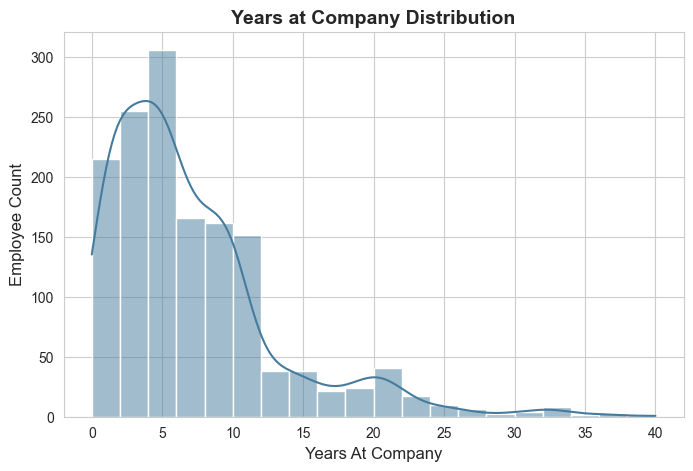

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='YearsAtCompany',
    bins=20,
    color='#457B9D',
    kde=True
)

plt.title(
    'Years at Company Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Years At Company')
plt.ylabel('Employee Count')

plt.show()

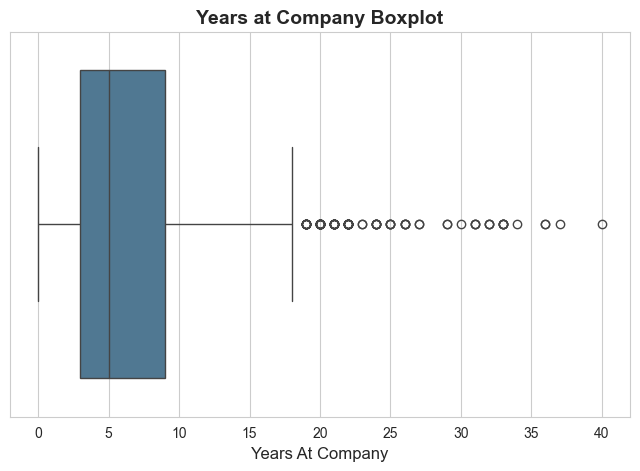

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['YearsAtCompany'],
    color='#457B9D'
)

plt.title(
    'Years at Company Boxplot',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Years At Company')

plt.show()

In [33]:
pd.crosstab(
    df['YearsAtCompany'],
    df['Attrition']
)

Attrition,No,Yes
YearsAtCompany,,
0,28,16
1,112,59
2,100,27
3,108,20
4,91,19
5,175,21
6,67,9
7,79,11
8,71,9


In [34]:
years_rate = pd.crosstab(
    df['YearsAtCompany'],
    df['Attrition'],
    normalize='index'
) * 100

years_rate

Attrition,No,Yes
YearsAtCompany,,
0,63.636364,36.363636
1,65.497076,34.502924
2,78.740157,21.259843
3,84.375000,15.625000
4,82.727273,17.272727
5,89.285714,10.714286
6,88.157895,11.842105
7,87.777778,12.222222
8,88.750000,11.250000


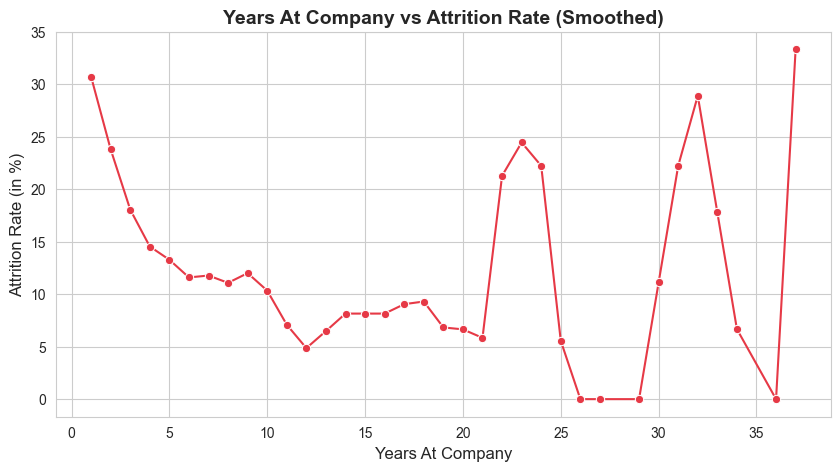

In [35]:
years_rate['Yes_Smoothed'] = (
    years_rate['Yes']
    .rolling(window=3, center=True)
    .mean()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=years_rate.index,
    y=years_rate['Yes_Smoothed'],
    marker='o',
    color='#E63946'
)

plt.title(
    'Years At Company vs Attrition Rate (Smoothed)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Years At Company')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Years at Company vs Attrition Analysis

### Findings

- Attrition rates vary across different tenure periods.
- Early-career employees show comparatively higher attrition.
- Mid and long-term employees generally display improved retention patterns.
- Some sharp fluctuations may occur due to smaller employee counts in certain tenure groups.

### Insight

Employee tenure appears to influence attrition behavior, but the relationship is not perfectly linear.

Employees in their initial years may be more likely to leave due to:

- onboarding adjustment
- career exploration
- role dissatisfaction
- limited organizational attachment

Employees with longer tenure often develop stronger workplace familiarity, organizational commitment, and role stability, reducing their likelihood of attrition.

In [36]:
pd.crosstab(
    df['TotalWorkingYears'],
    df['Attrition']
)

Attrition,No,Yes
TotalWorkingYears,,
0,6,5
1,41,40
2,22,9
3,33,9
4,51,12
5,72,16
6,103,22
7,63,18
8,87,16


In [37]:
twy_rate = pd.crosstab(
    df['TotalWorkingYears'],
    df['Attrition'],
    normalize='index'
) * 100

twy_rate

Attrition,No,Yes
TotalWorkingYears,,
0,54.545455,45.454545
1,50.617284,49.382716
2,70.967742,29.032258
3,78.571429,21.428571
4,80.952381,19.047619
5,81.818182,18.181818
6,82.400000,17.600000
7,77.777778,22.222222
8,84.466019,15.533981


In [38]:
twy_rate['Yes_Smoothed'] = (
    twy_rate['Yes']
    .rolling(window=3, center=True)
    .mean()
)

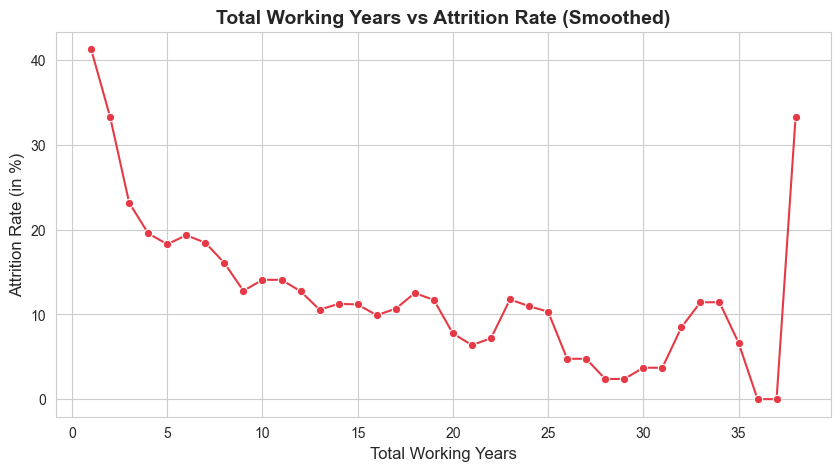

In [39]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=twy_rate.index,
    y=twy_rate['Yes_Smoothed'],
    marker='o',
    color='#E63946'
)

plt.title(
    'Total Working Years vs Attrition Rate (Smoothed)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Total Working Years')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Total Working Years vs Attrition Analysis

### Findings:

- Employees with lower total working experience show the highest attrition rates (~40%+ in early years).
- Attrition generally decreases as total working years increase.
- Employees with moderate to high work experience show relatively lower attrition.
- Minor spikes at extreme experience values likely result from smaller employee counts.

### Insight:

Overall professional experience appears to influence employee retention.

Employees with limited work experience may be more likely to leave because of:

- career exploration
- salary growth expectations
- skill development opportunities
- job switching behavior in early career stages

More experienced employees appear comparatively stable and less likely to leave the organization.

In [40]:
pd.crosstab(
    df['StockOptionLevel'],
    df['Attrition']
)

Attrition,No,Yes
StockOptionLevel,,
0,477,154
1,540,56
2,146,12
3,70,15


In [41]:
stock_rate = pd.crosstab(
    df['StockOptionLevel'],
    df['Attrition'],
    normalize='index'
) * 100

stock_rate

Attrition,No,Yes
StockOptionLevel,,
0,75.594295,24.405705
1,90.604027,9.395973
2,92.405063,7.594937
3,82.352941,17.647059


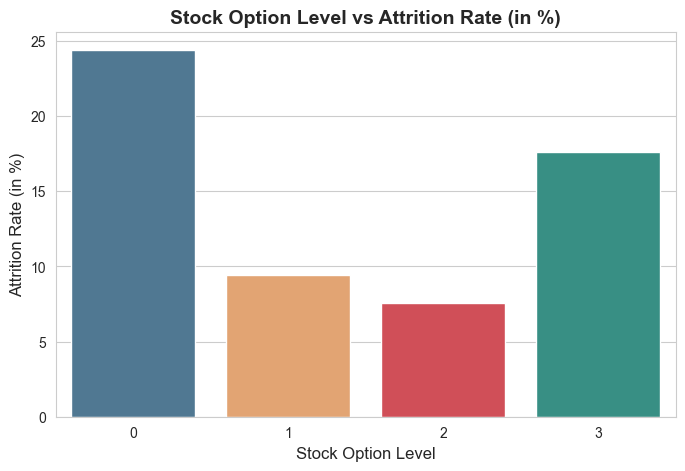

In [42]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=stock_rate.index,
    y=stock_rate['Yes'],
    hue=stock_rate.index,
    palette=['#457B9D', '#F4A261', '#E63946', '#2A9D8F'],
    legend=False
)

plt.title(
    'Stock Option Level vs Attrition Rate (in %)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Stock Option Level')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Stock Option Level vs Attrition Analysis

### Findings:

- Employees with Stock Option Level 0 show the highest attrition rate (~24%).
- Attrition drops significantly for Stock Option Levels 1 and 2.
- Stock Option Level 2 has the lowest attrition (~8%).
- Level 3 shows a moderate increase, likely influenced by a smaller employee population.

### Insight:

Employee ownership incentives appear associated with employee retention.

Employees without stock benefits may be more likely to leave because of:

- lower long-term organizational attachment
- reduced financial motivation
- fewer retention incentives

Providing stock options or equity-based rewards may contribute to stronger employee commitment and lower turnover.

# Work Environment Analysis

In [43]:
df['Department'].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

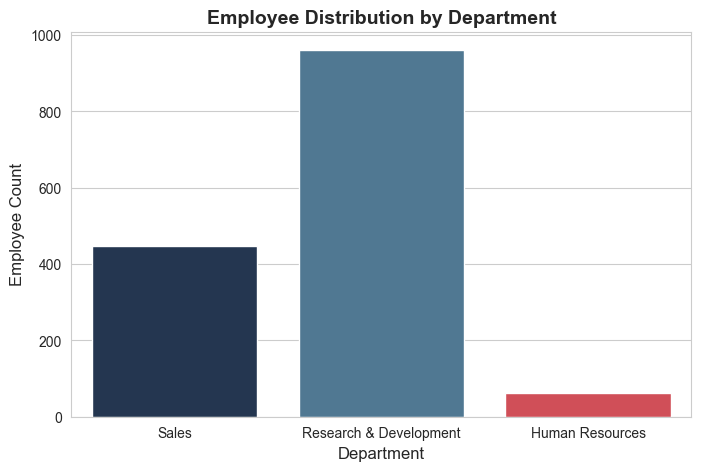

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Department',
    hue='Department',
    data=df,
    palette=['#1D3557', '#457B9D', '#E63946'],
    legend=False
)

plt.title('Employee Distribution by Department',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Employee Count')

plt.show()

In [45]:
pd.crosstab(df['Department'], df['Attrition'])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [46]:
dept_attrition_rate = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

dept_attrition_rate

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


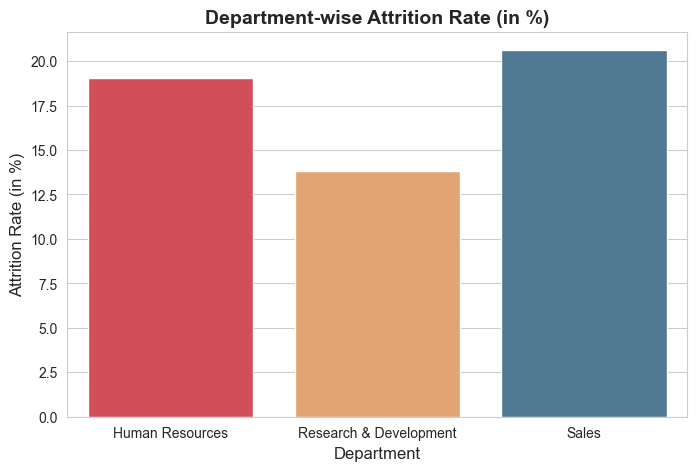

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=dept_attrition_rate.index,
    y=dept_attrition_rate['Yes'],
    hue=dept_attrition_rate.index,
    palette=['#E63946', '#F4A261', '#457B9D'],
    legend=False
)

plt.title('Department-wise Attrition Rate (in %)',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Department-wise Attrition Analysis

We analyzed employee attrition across departments.

### Findings:

- Sales department has the highest attrition rate (~20.6%).
- Human Resources shows moderate attrition (~19%).
- Research & Development has the lowest attrition (~13.8%).

### Insight:

Employees in Sales appear more likely to leave the organization compared to other departments. This may indicate higher workload, pressure, targets, or job dissatisfaction.

In [48]:
pd.crosstab(
    df['BusinessTravel'],
    df['Attrition']
)

Attrition,No,Yes
BusinessTravel,,
Non-Travel,138,12
Travel_Frequently,208,69
Travel_Rarely,887,156


In [49]:
travel_rate = pd.crosstab(
    df['BusinessTravel'],
    df['Attrition'],
    normalize='index'
) * 100

travel_rate

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


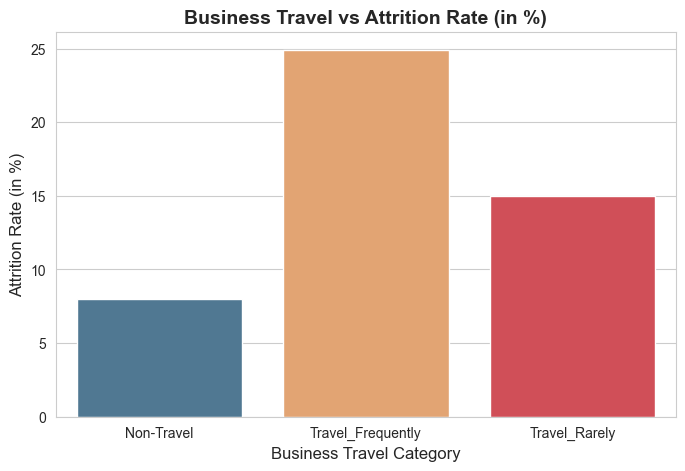

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=travel_rate.index,
    y=travel_rate['Yes'],
    hue=travel_rate.index,
    palette=['#457B9D', '#F4A261', '#E63946'],
    legend=False
)

plt.title(
    'Business Travel vs Attrition Rate (in %)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Business Travel Category')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Business Travel vs Attrition Analysis

### Findings:
Travel_Frequently employees show the highest attrition rate (~25%).
Travel_Rarely employees have moderate attrition (~15%).
Non-Travel employees show the lowest attrition (~8%).

Clear pattern observed:

more business travel → higher attrition tendency.

### Insight:

Frequent business travel appears strongly associated with employee turnover.

Heavy travel requirements may contribute to:

fatigue
schedule disruption
reduced personal/family time
work-life imbalance
burnout

Employees who travel frequently may experience greater pressure, increasing the likelihood of leaving.

In [51]:
pd.crosstab(
    df['DistanceFromHome'],
    df['Attrition']
)

Attrition,No,Yes
DistanceFromHome,,
1,182,26
2,183,28
3,70,14
4,55,9
5,55,10
6,52,7
7,73,11
8,70,10
9,67,18


In [52]:
distance_rate =pd.crosstab(
    df['DistanceFromHome'],
    df['Attrition'],
    normalize='index'
) * 100

distance_rate

Attrition,No,Yes
DistanceFromHome,,
1,87.500000,12.500000
2,86.729858,13.270142
3,83.333333,16.666667
4,85.937500,14.062500
5,84.615385,15.384615
6,88.135593,11.864407
7,86.904762,13.095238
8,87.500000,12.500000
9,78.823529,21.176471


In [53]:
distance_rate =pd.crosstab(
    df['DistanceFromHome'],
    df['Attrition'],
    normalize='index'
) * 100

distance_rate

Attrition,No,Yes
DistanceFromHome,,
1,87.500000,12.500000
2,86.729858,13.270142
3,83.333333,16.666667
4,85.937500,14.062500
5,84.615385,15.384615
6,88.135593,11.864407
7,86.904762,13.095238
8,87.500000,12.500000
9,78.823529,21.176471


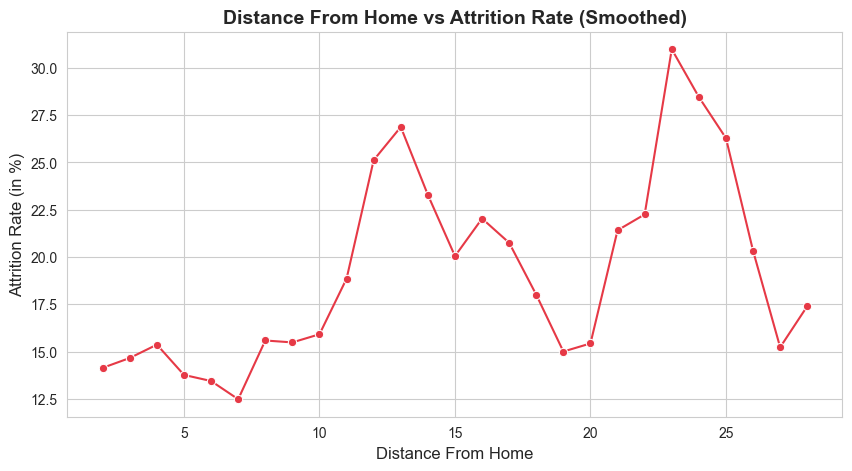

In [54]:
distance_rate['Yes_Smoothed'] = (
    distance_rate['Yes']
    .rolling(window=3, center=True)
    .mean()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=distance_rate.index,
    y=distance_rate['Yes_Smoothed'],
    marker='o',
    color='#E63946'
)

plt.title(
    'Distance From Home vs Attrition Rate (Smoothed)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Distance From Home')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Distance From Home vs Attrition Analysis

### Findings:
Attrition rate varies across different Distance From Home values.
Employees living closer to work (≈1–10) mostly show attrition around 12–16%.
Some mid-to-high distance values (≈12,13,22,24) show noticeable spikes.
The highest spike appears near Distance = 24 (~43%).
The pattern is not smooth or steadily increasing.

### Insight:

Distance from home may influence attrition, but the relationship does not appear strongly linear.

Longer commute can contribute to:

fatigue
travel burden
reduced work-life balance
lower job satisfaction

However, some spikes may occur because certain distance groups have very few employees, making percentages unstable.

In [55]:
pd.crosstab(
    df['OverTime'],
    df['Attrition']
)

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [56]:
overtime_rate = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

overtime_rate

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


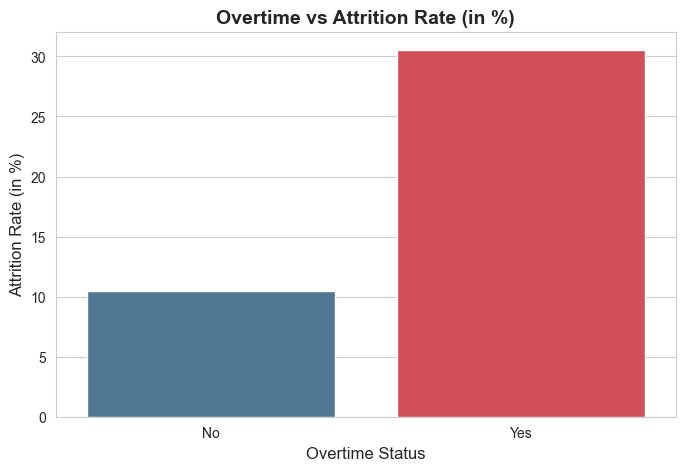

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=overtime_rate.index,
    y=overtime_rate['Yes'],
    hue=overtime_rate.index,
    palette=['#457B9D', '#E63946'],
    legend=False
)

plt.title(
    'Overtime vs Attrition Rate (in %)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Overtime Status')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Overtime vs Attrition Analysis

### Findings:

- Employees working overtime show significantly higher attrition.
- Non-overtime employees display much lower turnover rates.
- A clear difference exists between overtime and non-overtime groups.

### Insight:

Overtime appears strongly associated with employee attrition.

Employees working excessive overtime may experience:

- workload pressure
- fatigue and burnout
- reduced work-life balance
- increased job dissatisfaction

Managing overtime practices may help organizations improve employee retention.

### Business Impact:

The strong relationship between overtime and employee attrition suggests that workload management should be a priority area for organizations.

Reducing excessive overtime, improving scheduling practices, and strengthening work-life balance policies may help reduce employee turnover and improve retention.

In [58]:
pd.crosstab(
    df['TrainingTimesLastYear'],
    df['Attrition']
)

Attrition,No,Yes
TrainingTimesLastYear,,
0,39,15
1,62,9
2,449,98
3,422,69
4,97,26
5,105,14
6,59,6


In [59]:
training_rate = pd.crosstab(
    df['TrainingTimesLastYear'],
    df['Attrition'],
    normalize='index'
) * 100

training_rate

Attrition,No,Yes
TrainingTimesLastYear,,
0,72.222222,27.777778
1,87.323944,12.676056
2,82.084095,17.915905
3,85.947047,14.052953
4,78.861789,21.138211
5,88.235294,11.764706
6,90.769231,9.230769


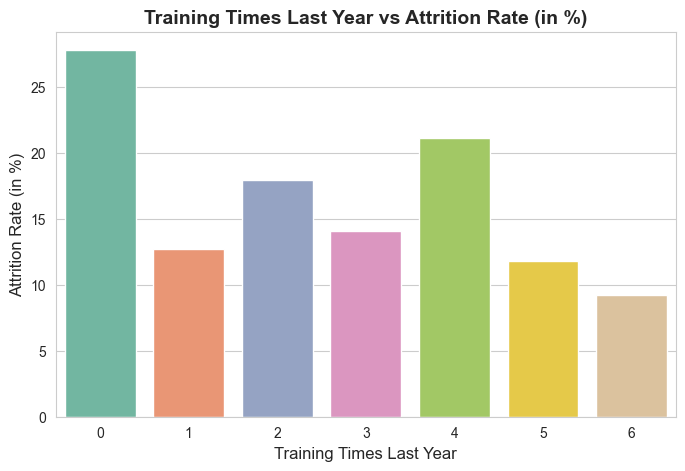

In [60]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=training_rate.index,
    y=training_rate['Yes'],
    hue=training_rate.index,
    palette='Set2',
    legend=False
)

plt.title(
    'Training Times Last Year vs Attrition Rate (in %)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Training Times Last Year')
plt.ylabel(('Attrition Rate (in %)'))

plt.show()

## Training Times Last Year vs Attrition Analysis

### Findings:

- Employees receiving no training sessions (0 trainings) show the highest attrition rate (~28%).
- Attrition generally decreases among employees receiving more training opportunities.
- Employees with 5–6 training sessions show comparatively lower attrition rates.
- Some intermediate fluctuations exist, but the overall trend suggests training may influence retention.

### Insight:

Employee training and development appear associated with employee retention.

Employees receiving limited or no training may be more likely to leave because of:

- reduced skill development opportunities
- slower career growth
- lower engagement with organizational learning programs

Providing regular training opportunities may improve employee satisfaction, professional growth, and long-term retention.

# Employee Satisfaction Analysis

In [61]:
# Calculate attrition frequency across job satisfaction levels
pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition']
)

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [62]:
# Convert counts into attrition percentages for fair comparison
job_sat_rate = pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

job_sat_rate

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


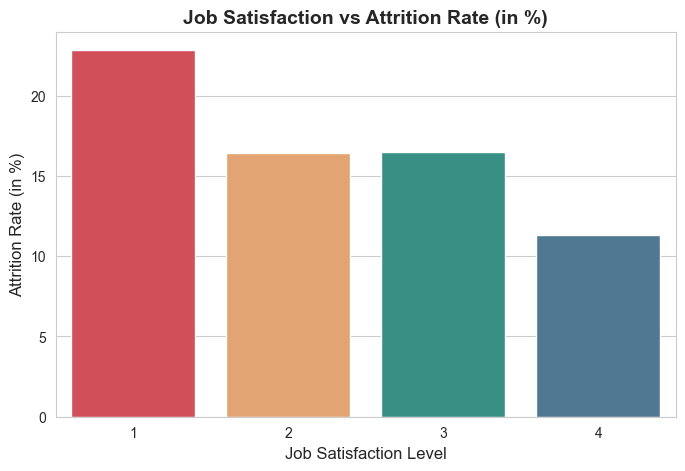

In [63]:
# Visualize attrition rate by job satisfaction category
plt.figure(figsize=(8,5))

sns.barplot(
    x=job_sat_rate.index,
    y=job_sat_rate['Yes'],
    hue=job_sat_rate.index,
    palette=['#E63946', '#F4A261', '#2A9D8F', '#457B9D'],
    legend=False
)

plt.title('Job Satisfaction vs Attrition Rate (in %)',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Job Satisfaction vs Attrition Analysis

### Findings:

- Employees with Job Satisfaction Level 1 show the highest attrition (~22.8%).
- Attrition gradually decreases as job satisfaction increases.
- Employees with Job Satisfaction Level 4 have the lowest attrition (~11.3%).

### Insight:

A strong inverse relationship exists between job satisfaction and employee attrition.

Employees who are less satisfied with their jobs are significantly more likely to leave the organization.

This suggests that improving employee satisfaction, workplace culture, recognition, and career growth opportunities may help improve employee retention.

### Business Impact:

The relationship between job satisfaction and employee attrition indicates that employee engagement and workplace experience are important organizational concerns.

Improving employee recognition, workplace culture, role satisfaction, and growth opportunities may help strengthen employee commitment and reduce turnover risk.

In [64]:
pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition']
)

Attrition,No,Yes
WorkLifeBalance,,
1,55,25
2,286,58
3,766,127
4,126,27


In [65]:
wlb_rate = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
) * 100

wlb_rate

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


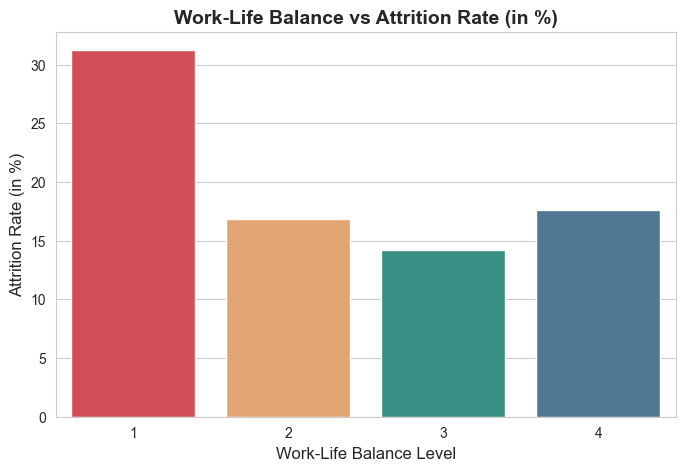

In [66]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=wlb_rate.index,
    y=wlb_rate['Yes'],
    hue=wlb_rate.index,
    palette=['#E63946', '#F4A261', '#2A9D8F', '#457B9D'],
    legend=False
)

plt.title(
    'Work-Life Balance vs Attrition Rate (in %)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Work-Life Balance Level')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Work Life Balance vs Attrition Analysis

### Findings:

- Work-Life Balance Level 1 shows the highest attrition rate (~31%).
- Level 3 has the lowest attrition (~14%).
- Employees with poor work-life balance appear more likely to leave.

### Insight:

Work-life balance seems to be an important factor affecting employee retention. Lower balance may indicate higher stress, burnout, or workload pressure.

In [67]:
pd.crosstab(
    df['EnvironmentSatisfaction'],
    df['Attrition']
)

Attrition,No,Yes
EnvironmentSatisfaction,,
1,212,72
2,244,43
3,391,62
4,386,60


In [68]:
env_rate = pd.crosstab(
    df['EnvironmentSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

env_rate

Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.647887,25.352113
2,85.017422,14.982578
3,86.313466,13.686534
4,86.547085,13.452915


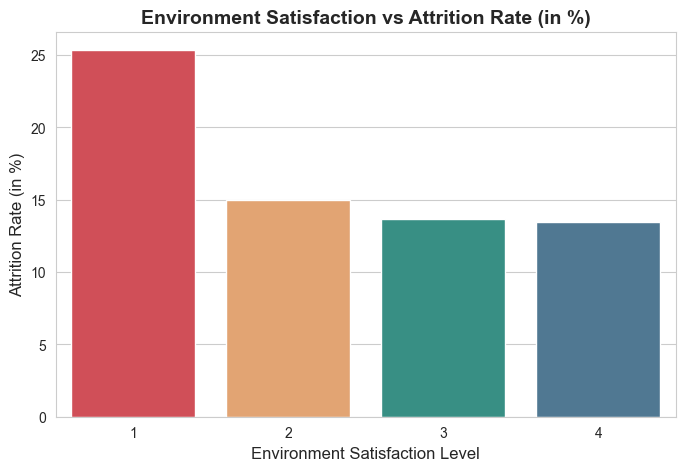

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=env_rate.index,
    y=env_rate['Yes'],
    hue=env_rate.index,
    palette=['#E63946', '#F4A261', '#2A9D8F', '#457B9D'],
    legend=False
)

plt.title(
    'Environment Satisfaction vs Attrition Rate (in %)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Environment Satisfaction Level'),
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Environment Satisfaction vs Attrition Analysis

### Findings:

- Environment Satisfaction Level 1 shows the highest attrition rate (~25%).
- Levels 2–4 show significantly lower attrition (~13–15%).
- Employees dissatisfied with their work environment are more likely to leave.

### Insight:

Work environment satisfaction appears to be an important retention factor. Improving workplace culture and environment may help reduce employee turnover.

In [70]:
pd.crosstab(
    df['RelationshipSatisfaction'],
    df['Attrition']
)

Attrition,No,Yes
RelationshipSatisfaction,,
1,219,57
2,258,45
3,388,71
4,368,64


In [71]:
rel_rate = pd.crosstab(
    df['RelationshipSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

rel_rate

Attrition,No,Yes
RelationshipSatisfaction,,
1,79.347826,20.652174
2,85.148515,14.851485
3,84.531590,15.468410
4,85.185185,14.814815


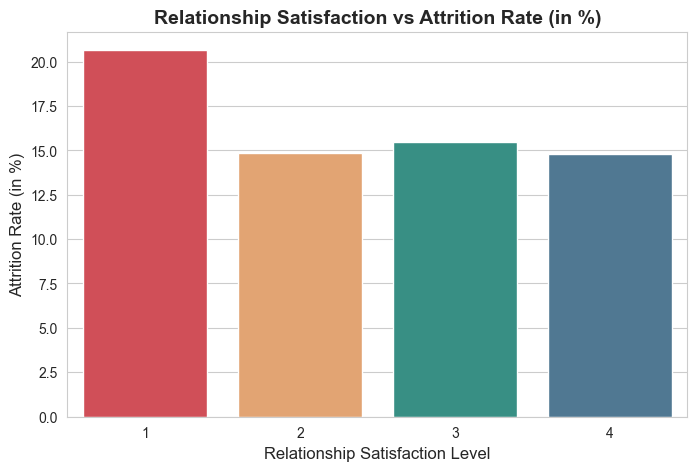

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=rel_rate.index,
    y=rel_rate['Yes'],
    hue=rel_rate.index,
    palette=['#E63946', '#F4A261', '#2A9D8F', '#457B9D'],
    legend=False
)

plt.title(
    'Relationship Satisfaction vs Attrition Rate (in %)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Relationship Satisfaction Level')
plt.ylabel('Attrition Rate (in %)')

plt.show()

## Relationship Satisfaction vs Attrition Analysis

### Findings:

- Relationship Satisfaction Level 1 shows the highest attrition rate (~20.7%).
- Levels 2–4 show relatively similar attrition (~14–15%).
- Poor workplace relationship satisfaction appears associated with higher employee turnover.

### Insight:

Employee relationships may influence retention. Poor interactions with colleagues or managers can increase the likelihood of attrition.

# Correlation Analysis

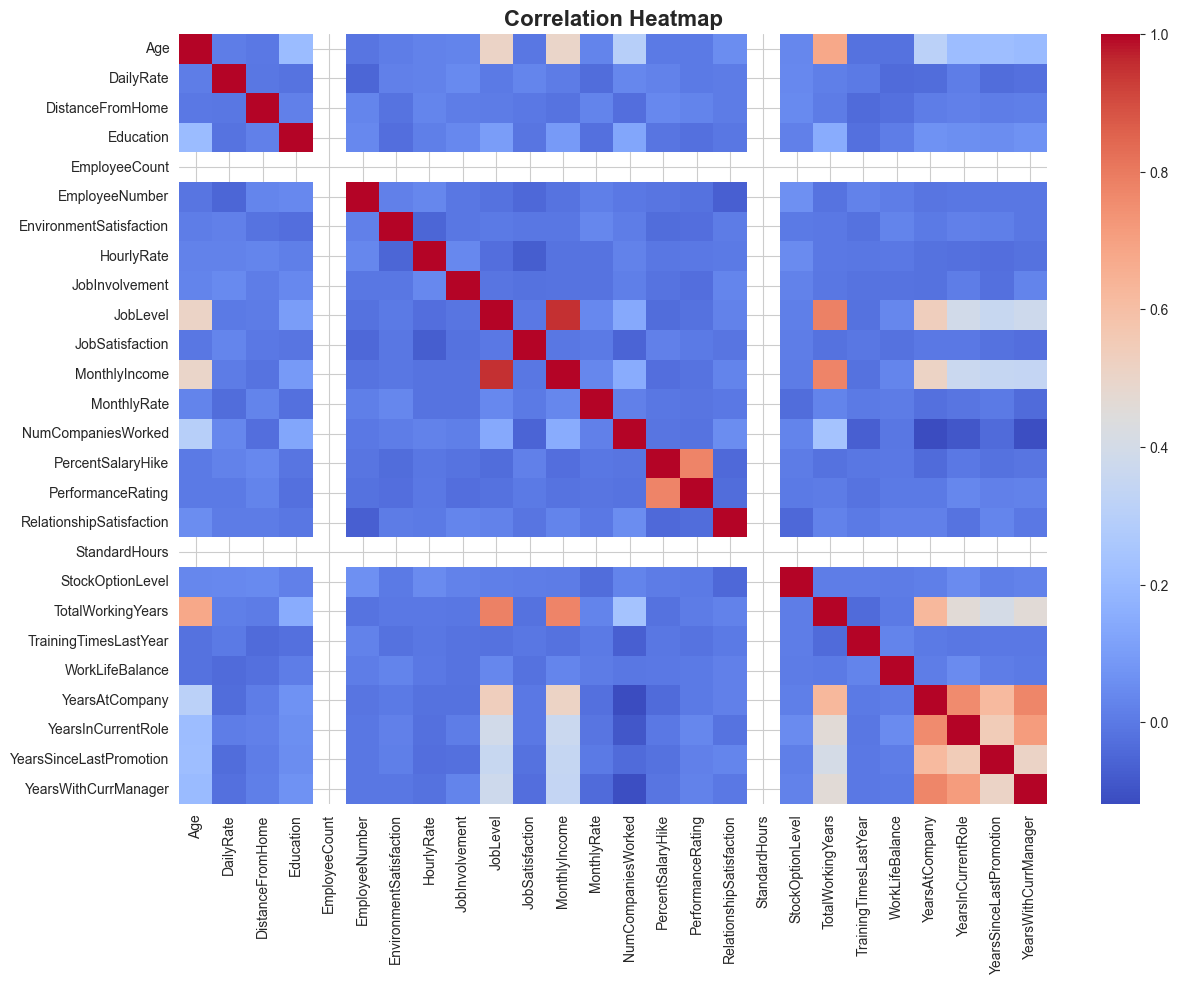

In [73]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    cmap='coolwarm',
    annot=False
)

plt.title(
    'Correlation Heatmap',
    fontsize=16,
    fontweight='bold'
)

plt.show()

### Findings:

- Most variables exhibit weak-to-moderate correlations.
- Experience-related features show stronger relationships with one another.
- Employee attrition appears influenced by multiple interacting factors rather than a single dominant variable.

### Insight:

The correlation analysis suggests that employee turnover is a multidimensional problem involving compensation, satisfaction, work environment, and employee experience factors.

This reinforces the importance of analyzing employee attrition using multiple perspectives instead of relying on a single metric.

# Key Findings Summary Table

| Factor | Observation | Impact on Attrition |
|---------|-------------|---------------------|
| OverTime | Overtime employees showed significantly higher attrition | Strong |
| Job Satisfaction | Lower satisfaction linked with higher attrition | Strong |
| WorkLifeBalance | Poorer balance associated with employee exits | Strong |
| Monthly Income | Lower income employees tended to leave more | Moderate–Strong |
| Job Level | Lower job levels showed greater attrition | Moderate |
| Business Travel | Frequent travel increased attrition tendency | Moderate |
| Years At Company | Lower tenure employees left more frequently | Moderate |
| Total Working Years | Early-career employees showed higher attrition | Moderate |
| Stock Option Level | Employees without stock benefits had higher attrition | Moderate |

# Final Conclusion

This exploratory data analysis identified several important factors associated with employee attrition.

### Key Findings:

- Employees working overtime show significantly higher attrition.
- Lower job satisfaction and poorer work-life balance are linked with higher employee turnover.
- Lower income employees and lower job levels demonstrate stronger attrition tendencies.
- Employees with shorter tenure and lower total working experience are more likely to leave.
- Frequent business travel appears associated with increased attrition.
- Training opportunities and stock benefits may positively influence retention.

### Business Insight:

Employee attrition appears influenced by a combination of:

- workload factors
- compensation & career growth
- employee satisfaction
- work environment conditions
- employee experience and organizational attachment

Organizations may improve retention by focusing on employee wellbeing, workload management, career development, and compensation strategies.

## Key Takeaways

The analysis suggests that employee attrition is not driven by a single factor.

Instead, attrition appears to be influenced by a combination of:

- workload and overtime pressure
- employee satisfaction levels
- compensation and career progression
- work environment conditions
- employee experience and organizational attachment

Among the analyzed variables, overtime, work-life balance, compensation factors, and employee experience demonstrated some of the strongest relationships with attrition behavior.

# Next Phase of the Project

This exploratory analysis forms the foundation for the next stage of the Employee Attrition Prediction project.

Based on the insights obtained from EDA, the next phase will involve:

- feature preprocessing and encoding
- machine learning model development
- employee attrition prediction
- model evaluation and performance comparison
- development of a web-based prediction interface

The final objective is to build an intelligent employee attrition prediction system capable of supporting proactive retention decision-making.